In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 

# Euler

In [2]:
#Euler - need to update position, velocity, and accel in both x and y
def Euler(x,y,vx,vy,time,dt):
    '''
    x, y, vx, and vy are the initial params given. Time is how long I want the loop to go for and dt is the step size. 
    '''

    x_vals = [x]
    y_vals = [y]
    vx_vals = [vx]
    vy_vals = [vy]
    
    #calculate initial energy
    r = np.sqrt(x**2 + y**2)
    e = 0.5*(vx**2 + vy**2) - G*M/r
    
    e_vals = [e]
  
    steps = int(time/dt) 
    
    for i in range(steps):
        r = np.sqrt(x**2 + y**2) #compute position first

        #accel in x and y from position
        ax = -G*M*x/r**3
        ay = -G*M*y/r**3

        x_new  = x + vx*dt
        y_new  = y + vy*dt
        vx_new = vx + ax*dt
        vy_new = vy + ay*dt

        #calc energies
        r_new = np.sqrt(x_new**2 + y_new**2)
        e = 0.5*(vx_new**2 + vy_new**2) - G*M/r_new
        
        #updating params 
        x = x_new
        y = y_new
        vx = vx_new
        vy = vy_new
        
        x_vals.append(x)
        y_vals.append(y)
        vx_vals.append(vx)
        vy_vals.append(vy)
        e_vals.append(e)

    t_vals = np.linspace(0, time, steps + 1)

    return np.array(x_vals), np.array(y_vals), np.array(vx_vals), np.array(vy_vals), np.array(e_vals), t_vals

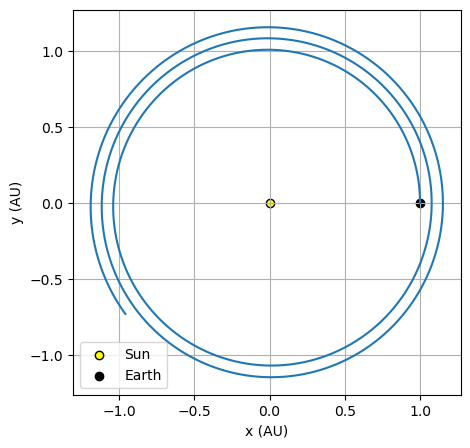

In [3]:
#testing Euler
#Orbital mech eqns - but need to do in x and y. Using params given by hw
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Euler(x,y,0,vcirc,3,0.001)

plt.figure(figsize=(5,5))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.scatter(1,0,color="black",label="Earth",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.legend()
plt.grid()
plt.savefig("Euler_orbit.png",dpi=300)
plt.show()

In [4]:
#Figure stuff
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_title('Euler Orbit')

#Plotting stuff
earth, = ax.plot([], [], 'bo', markersize = 6, label = 'Earth')
trail, = ax.plot([], [], 'k-', alpha = 0.5, label = 'Orbit')
ax.plot(0, 0, 'yo', markersize = 12, label = 'Sun')
ax.grid()
ax.legend()

def init():
    earth.set_data([], [])
    trail.set_data([], [])
    return earth, trail

#Update function
frame_step = 10
def update(frame):
    idx = frame * frame_step #frame steps
    earth.set_data([x[idx]], [y[idx]]) #earth position updates
    trail.set_data(x[:idx], y[:idx]) #orbit trail updates
    
    return earth, trail

#Animation
total_frames = len(x) // frame_step
ani = FuncAnimation(fig, update, frames = total_frames, init_func = init, blit = True, interval = 20)
plt.close() 

#save as gif
ani.save('euler.gif', writer='pillow', fps=30)

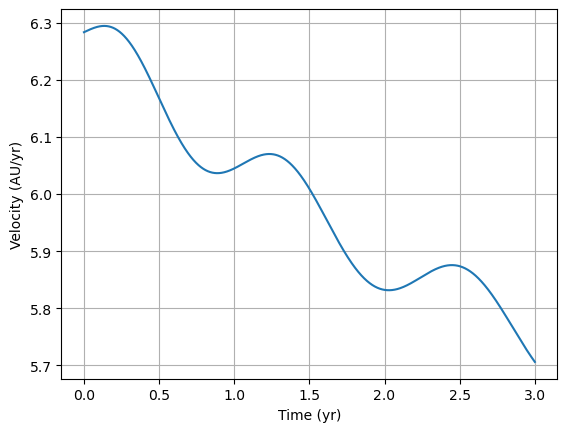

In [5]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Euler(x,y,0,vcirc,3,0.001)

plt.plot(t, np.sqrt(vx**2+vy**2))
plt.xlabel("Time (yr)")
plt.ylabel("Velocity (AU/yr)")
plt.grid()
plt.savefig("Euler_velocity.png",dpi=300)
plt.show()

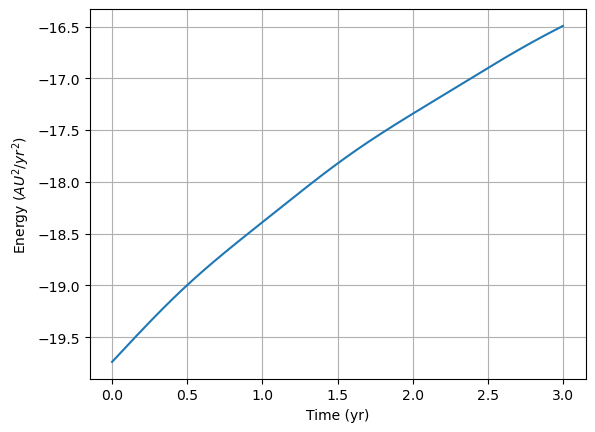

In [6]:
plt.plot(t, e)
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.grid()
plt.savefig("Euler_energy.png",dpi=300)
plt.show()

In [7]:
e[0], e[-1]

(np.float64(-19.739208802178716), np.float64(-16.4936581790178))

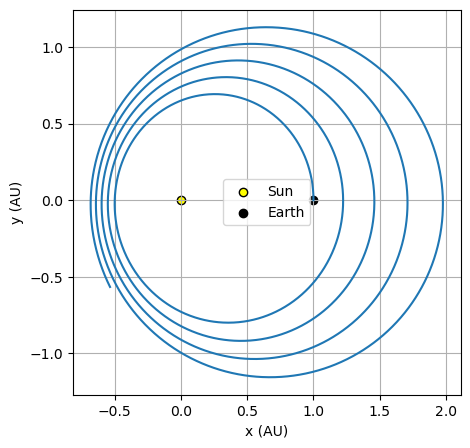

In [8]:
#0.8*vcirc
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Euler(x,y,0,0.8*vcirc,5,0.001)

plt.figure(figsize=(5,5))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.scatter(1,0,color="black",label="Earth",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.legend()
plt.grid()
plt.savefig("Euler_orbit5.png",dpi=300)
plt.show()

In [9]:
#Figure stuff
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlim(-1.5, 2)
ax.set_ylim(-1.5, 2)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_title('Euler Orbit with v=0.8vcirc')

#Plotting stuff
earth, = ax.plot([], [], 'bo', markersize = 6, label = 'Earth')
trail, = ax.plot([], [], 'k-', alpha = 0.5, label = 'Orbit')
ax.plot(0, 0, 'yo', markersize = 12, label = 'Sun')
ax.grid()
ax.legend()

def init():
    earth.set_data([], [])
    trail.set_data([], [])
    return earth, trail

#Update function
frame_step = 10 
def update(frame):
    idx = frame * frame_step #frame steps
    earth.set_data([x[idx]], [y[idx]]) #earth position updates
    trail.set_data(x[:idx], y[:idx]) #orbit trail updates
    
    return earth, trail

#Animation
total_frames = len(x) // frame_step
ani = FuncAnimation(fig, update, frames = total_frames, init_func = init, blit = True, interval = 20)
plt.close() 

#save as gif
ani.save('euler5.gif', writer='pillow', fps=30)

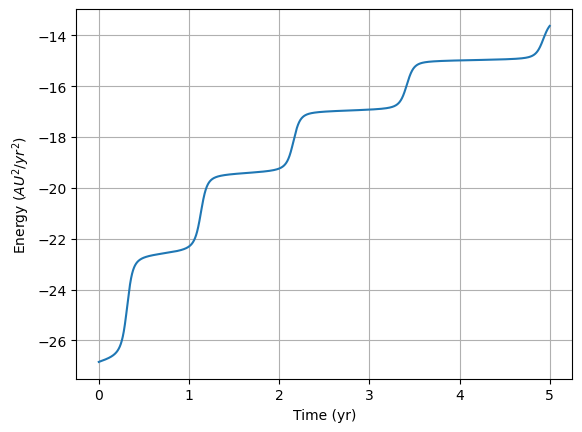

In [10]:
plt.plot(t, e)
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.grid()
plt.savefig("Euler_5energy.png",dpi=300)
plt.show()

# Leapfrog

In [11]:
#Leapfrog
def Leapfrog(x,y,vx,vy,time,dt):

    x_vals = [x]
    y_vals = [y]
    vx_vals = [vx]
    vy_vals = [vy]
  
    #calculate initial energy
    r = np.sqrt(x**2 + y**2)
    e = 0.5*(vx**2 + vy**2) - G*M/r
    
    e_vals = [e]

    steps = int(time/dt)
    
    for i in range(steps):
        r = np.sqrt(x**2 + y**2) #compute position first
        ax = -G*M*x/r**3
        ay = -G*M*y/r**3
        
        #first kick (half-interval)
        vx_fhalf = vx + 0.5*ax*dt
        vy_fhalf = vy + 0.5*ay*dt
    
        #drift from first kick 
        x_new = x + vx_fhalf*dt
        y_new = y + vy_fhalf*dt

        #accel and energy from drift
        r_new = np.sqrt(x_new**2 + y_new**2)
        ax_drift = -G*M*x_new/r_new**3
        ay_drift = -G*M*y_new/r_new**3
    
        #second kick (half-interval) - this makes the full time step
        vx_shalf = vx_fhalf + 0.5*ax_drift*dt
        vy_shalf = vy_fhalf + 0.5*ay_drift*dt
 
        #calc energies
        e = 0.5*(vx_shalf**2 + vy_shalf**2) - G*M/r_new
    
        #updating params 
        x = x_new
        y = y_new
        vx = vx_shalf
        vy = vy_shalf

        x_vals.append(x)
        y_vals.append(y)
        vx_vals.append(vx)
        vy_vals.append(vy)
        e_vals.append(e)

    t_vals = np.linspace(0, steps*dt, steps + 1)
    
    return np.array(x_vals), np.array(y_vals), np.array(vx_vals), np.array(vy_vals), np.array(e_vals), t_vals

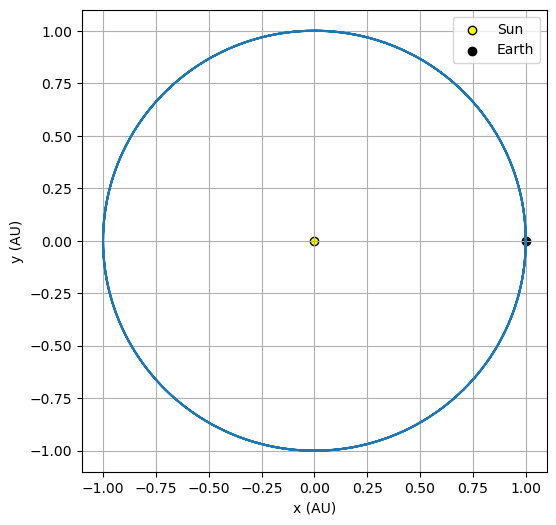

In [12]:
#testing leapfrog
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Leapfrog(x,y,0,vcirc,3,0.001)

plt.figure(figsize=(6,6))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.scatter(1,0,color="black",label="Earth",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.legend()
plt.grid()
plt.savefig("Leapfrog_orbit.png",dpi=300)
plt.show()

In [13]:
#Figure stuff
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_title('Leapfrog Orbit')

#Plotting stuff
earth, = ax.plot([], [], 'bo', markersize = 6, label = 'Earth')
trail, = ax.plot([], [], 'k-', alpha = 0.5, label = 'Orbit')
ax.plot(0, 0, 'yo', markersize = 12, label = 'Sun')
ax.grid()
ax.legend()

def init():
    earth.set_data([], [])
    trail.set_data([], [])
    return earth, trail

#Update function
frame_step = 10
def update(frame):
    idx = frame * frame_step #frame steps
    earth.set_data([x[idx]], [y[idx]]) #earth position updates
    trail.set_data(x[:idx], y[:idx]) #orbit trail updates
    
    return earth, trail

#Animation
total_frames = len(x) // frame_step
ani = FuncAnimation(fig, update, frames = total_frames, init_func = init, blit = True, interval = 20)
plt.close() 

#save as gif
ani.save('leapfrog.gif', writer='pillow', fps=30)

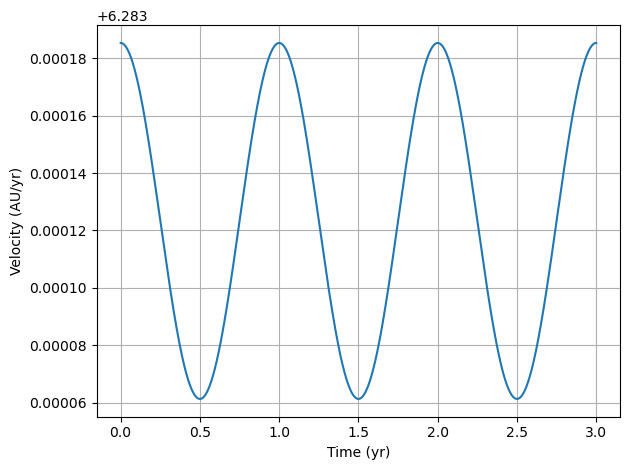

In [19]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Leapfrog(x,y,0,vcirc,3,0.001)

plt.plot(t, np.sqrt(vx**2+vy**2))
plt.xlabel("Time (yr)")
plt.ylabel("Velocity (AU/yr)")
plt.grid()
plt.tight_layout()
plt.savefig("Leapfrog_velocity.png",dpi=300)
plt.show()

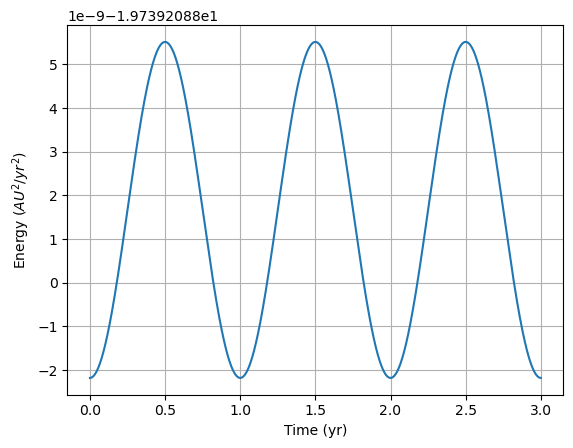

In [20]:
plt.plot(t, e)
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.grid()
plt.savefig("Leapfrog_energy.png",dpi=300)
plt.show()

In [21]:
e[0],e[-1]

(np.float64(-19.739208802178716), np.float64(-19.73920880217888))

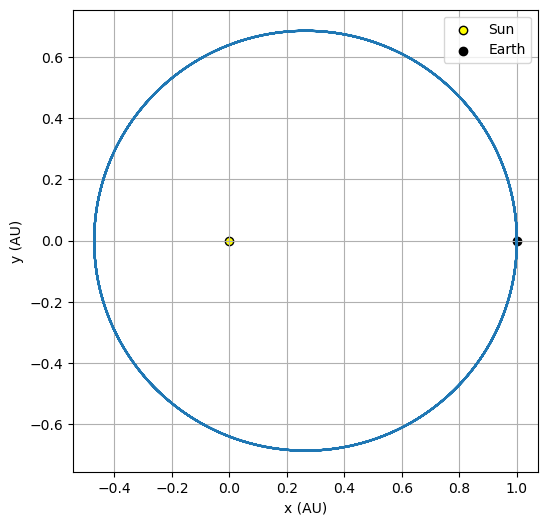

In [22]:
#0.8*vcirc
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,e,t = Leapfrog(x,y,0,0.8*vcirc,5,0.001)

plt.figure(figsize=(6,6))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.scatter(1,0,color="black",label="Earth",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.legend()
plt.grid()
plt.savefig("Leapfrog_orbit5.png",dpi=300)
plt.show()

In [ ]:
#Figure stuff
fig, ax = plt.subplots(figsize = (6, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_title('Leapfrog Orbit with v=0.8vcirc')

#Plotting stuff
earth, = ax.plot([], [], 'bo', markersize = 6, label = 'Earth')
trail, = ax.plot([], [], 'k-', alpha = 0.5, label = 'Orbit')
ax.plot(0, 0, 'yo', markersize = 12, label = 'Sun')
ax.grid()
ax.legend()

def init():
    earth.set_data([], [])
    trail.set_data([], [])
    return earth, trail

#Update function
frame_step = 10
def update(frame):
    idx = frame * frame_step #frame steps
    earth.set_data([x[idx]], [y[idx]]) #earth position updates
    trail.set_data(x[:idx], y[:idx]) #orbit trail updates
    
    return earth, trail

#Animation
total_frames = len(x) // frame_step
ani = FuncAnimation(fig, update, frames = total_frames, init_func = init, blit = True, interval = 20)
plt.close() 

#save as gif
ani.save('leapfrog5.gif', writer='pillow', fps=30)

In [ ]:
plt.plot(t, e)
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.grid()
plt.tight_layout()
plt.savefig("Leapfrog_5energy.png",dpi=300)
plt.show()

# Comparison plots

In [ ]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)


xE,yE,vxE,vyE,eE,t = Euler(x,y,0,vcirc,3,0.001)
xL,yL,vxL,vyL,eL,t = Leapfrog(x,y,0,vcirc,3,0.001)


plt.plot(t, np.sqrt(vxE**2+vyE**2),label="Euler")
plt.plot(t, np.sqrt(vxL**2+vyL**2),label="Leapfrog")
plt.xlabel("Time (yr)")
plt.ylabel("Velocity (AU/yr)")
plt.title("Velocities: Euler vs Leapfrog")
plt.grid()
plt.legend()
plt.savefig("E_L_Vel.png",dpi=300)
plt.show()

In [ ]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)


xE,yE,vxE,vyE,eE,t = Euler(x,y,0,vcirc,3,0.001)
xL,yL,vxL,vyL,eL,t = Leapfrog(x,y,0,vcirc,3,0.001)


plt.plot(t, eE,label="Euler")
plt.plot(t, eL,label="Leapfrog")
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.title("Energies: Euler vs Leapfrog")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("E_L_En.png",dpi=300)
plt.show()

In [ ]:
G = 4*np.pi**2
M = 1 #solar mass
x, y = 1,0 #AU
r = np.sqrt(x**2+y**2)
vcirc = np.sqrt(G*M/r)


xE,yE,vxE,vyE,eE,t = Euler(x,y,0,vcirc*0.8,3,0.001)
xL,yL,vxL,vyL,eL,t = Leapfrog(x,y,0,vcirc*0.8,3,0.001)


plt.plot(t, eE,label="Euler")
plt.plot(t, eL,label="Leapfrog")
plt.xlabel("Time (yr)")
plt.ylabel(r"Energy ($AU^{2}/yr^{2}$)")
plt.title("Energies: Euler vs Leapfrog")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("E_L_5En.png",dpi=300)
plt.show()

# Voyager

In [17]:
G = 4*np.pi**2
M_sun = 1
M_jup = 0.0009543

AU_TO_KM = 1.496e8
AUYR_TO_KMS = 4.743

In [18]:
# --- Jupiter ---
theta = np.pi / 3   # place ahead of Voyager

rJ = 5.2
xJ = rJ * np.cos(theta)
yJ = rJ * np.sin(theta)

vJ = np.sqrt(G*M_sun/rJ)
vxJ = -vJ * np.sin(theta)
vyJ =  vJ * np.cos(theta)

# --- Voyager ---
xV, yV = 1, 0

vE = np.sqrt(G*M_sun/1)

# boosted to reach Jupiter
vxV, vyV = 0, 1.2 * vE

In [12]:
def accel_sun(x, y):
    r = np.sqrt(x**2 + y**2)
    return -G*M_sun*x/r**3, -G*M_sun*y/r**3

def accel_jupiter_on_voyager(xV, yV, xJ, yJ):
    dx = xV - xJ
    dy = yV - yJ
    r = np.sqrt(dx**2 + dy**2)
    return -G*M_jup*dx/r**3, -G*M_jup*dy/r**3

In [21]:
def Leapfrog_3body(xV, yV, vxV, vyV,
                  xJ, yJ, vxJ, vyJ,
                  time, dt):

    steps = int(time/dt)

    xV_vals, yV_vals = [xV], [yV]
    xJ_vals, yJ_vals = [xJ], [yJ]
    vxV_vals, vyV_vals = [vxV], [vyV]

    for i in range(steps):

        # accelerations
        axJ, ayJ = accel_sun(xJ, yJ)

        axS, ayS = accel_sun(xV, yV)
        axJv, ayJv = accel_jupiter_on_voyager(xV, yV, xJ, yJ)
        axV, ayV = axS + axJv, ayS + ayJv

        # half kick
        vxJ_h = vxJ + 0.5*axJ*dt
        vyJ_h = vyJ + 0.5*ayJ*dt

        vxV_h = vxV + 0.5*axV*dt
        vyV_h = vyV + 0.5*ayV*dt

        # drift
        xJ_new = xJ + vxJ_h*dt
        yJ_new = yJ + vyJ_h*dt

        xV_new = xV + vxV_h*dt
        yV_new = yV + vyV_h*dt

        # new accelerations
        axJ_new, ayJ_new = accel_sun(xJ_new, yJ_new)

        axS_new, ayS_new = accel_sun(xV_new, yV_new)
        axJv_new, ayJv_new = accel_jupiter_on_voyager(xV_new, yV_new, xJ_new, yJ_new)
        axV_new, ayV_new = axS_new + axJv_new, ayS_new + ayJv_new

        # second half kick
        vxJ = vxJ_h + 0.5*axJ_new*dt
        vyJ = vyJ_h + 0.5*ayJ_new*dt

        vxV = vxV_h + 0.5*axV_new*dt
        vyV = vyV_h + 0.5*ayV_new*dt

        # update positions
        xJ, yJ = xJ_new, yJ_new
        xV, yV = xV_new, yV_new

        # store
        xJ_vals.append(xJ)
        yJ_vals.append(yJ)
        xV_vals.append(xV)
        yV_vals.append(yV)
        vxV_vals.append(vxV)
        vyV_vals.append(vyV)

    t_vals = np.linspace(0, time, steps+1)

    return (np.array(xV_vals), np.array(yV_vals),
            np.array(xJ_vals), np.array(yJ_vals),
            np.array(vxV_vals), np.array(vyV_vals),
            t_vals)

In [22]:
time = 12     # years (enough to reach Jupiter)
dt = 0.001

xV, yV, xJ, yJ, vxV, vyV, t = Leapfrog_3body(
    xV, yV, vxV, vyV,
    xJ, yJ, vxJ, vyJ,
    time, dt
)

In [15]:
# distance
dist = np.sqrt((xV - xJ)**2 + (yV - yJ)**2)
min_idx = np.argmin(dist)

closest_dist = dist[min_idx]
closest_time = t[min_idx]

# convert
closest_dist_km = closest_dist * AU_TO_KM
closest_time_months = closest_time * 12

# speed
v = np.sqrt(vxV**2 + vyV**2)
v_kms = v * AUYR_TO_KMS

# before/after comparison
window = 300
i0 = max(min_idx - window, 0)
i1 = min(min_idx + window, len(v_kms)-1)

v_before = np.mean(v_kms[i0:min_idx])
v_after  = np.mean(v_kms[min_idx:i1])

print(f"Closest approach: {closest_dist:.4f} AU ({closest_dist_km:.2e} km)")
print(f"Time: {closest_time_months:.2f} months")
print(f"Speed before: {v_before:.2f} km/s")
print(f"Speed after:  {v_after:.2f} km/s")
print(f"Delta v:      {v_after - v_before:.2f} km/s")

plt.figure(figsize=(6,6))
plt.plot(xV,yV)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.scatter(1,0,color="black",label="Voyager",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.legend()
plt.grid()
plt.show()

Closest approach: 2.6827 AU (4.01e+08 km)
Time: 41.30 months
Speed before: 15.05 km/s
Speed after:  13.98 km/s
Delta v:      -1.07 km/s


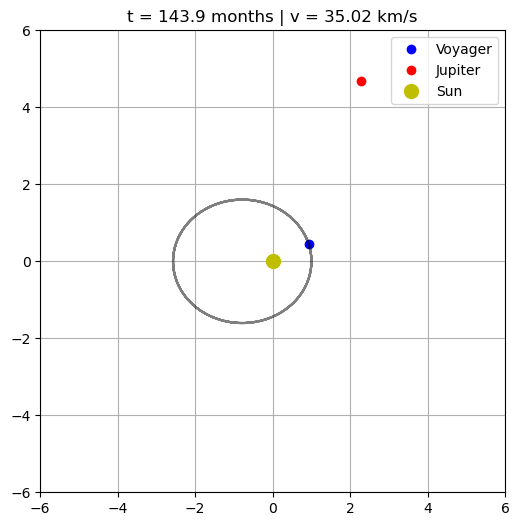

In [23]:
fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)

voyager_dot, = ax.plot([], [], 'bo', label='Voyager')
jupiter_dot, = ax.plot([], [], 'ro', label='Jupiter')
trail, = ax.plot([], [], 'k-', alpha=0.5)

ax.plot(0, 0, 'yo', markersize=10, label='Sun')
ax.legend()
ax.grid()

def init():
    voyager_dot.set_data([], [])
    jupiter_dot.set_data([], [])
    trail.set_data([], [])
    return voyager_dot, jupiter_dot, trail

frame_step = 10

def update(frame):
    idx = frame * frame_step

    voyager_dot.set_data([xV[idx]], [yV[idx]])
    jupiter_dot.set_data([xJ[idx]], [yJ[idx]])

    trail.set_data(xV[:idx], yV[:idx])

    months = t[idx] * 12
    speed = v_kms[idx]

    ax.set_title(f"t = {months:.1f} months | v = {speed:.2f} km/s")

    return voyager_dot, jupiter_dot, trail

frames = len(xV) // frame_step

ani = FuncAnimation(fig, update, frames=frames, init_func=init, blit=True)

ani.save("voyager.gif", writer="pillow", fps=30)

In [22]:
#Sun acting on Jupiter
G = 4*np.pi**2
M = 1 #solar mass

theta = np.pi / 3   #60 degrees ahead
xJ = 5.2 * np.cos(theta)
yJ = 5.2 * np.sin(theta)

vcircJ = np.sqrt(G*M/5.2)

# velocity perpendicular to radius (CCW orbit)
vxJ = -vcircJ * np.sin(theta)
vyJ =  vcircJ * np.cos(theta)

#Sun and Jupiter acting on Voyager
MJ = 0.0009543 #in solar masses
xV, yV = 0,1 #AU
rE = np.sqrt(xV**2+yV**2)
vcircV = np.sqrt(G*M/rE) #initial launch
vxV, vyV = 0, 1.2*vcircV

#Voyager affected by the Sun and Jupiter

In [4]:
G = 4*np.pi**2
M = 1
MJ = 0.0009543

# --- Jupiter ---
theta = np.pi / 3

rJ = 5.2
xJ = rJ * np.cos(theta)
yJ = rJ * np.sin(theta)

vcircJ = np.sqrt(G*M/rJ)
vxJ = -vcircJ * np.sin(theta)
vyJ =  vcircJ * np.cos(theta)

# --- Voyager ---
rE = 1
xV, yV = 0,1

vcircV = np.sqrt(G*M/rE)

# boosted velocity toward outer solar system
vxV, vyV = 0, 1.2 * vcircV

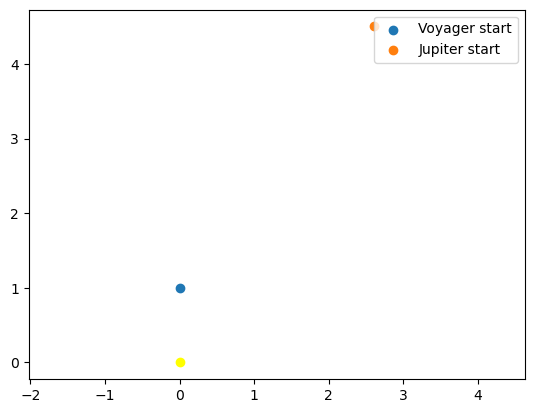

In [5]:
plt.scatter(0,0,color="yellow")
plt.scatter(xV,yV,label="Voyager start")
plt.scatter(xJ,yJ,label="Jupiter start")
plt.legend()
plt.axis("equal")
plt.show()

In [ ]:
#Leapfrog
def Leapfrog(x,y,vx,vy,time,dt):

    x_vals = [x]
    y_vals = [y]
    vx_vals = [vx]
    vy_vals = [vy]
  
    #calculate initial energy
    r = np.sqrt(x**2 + y**2)
    e = 0.5*(vx**2 + vy**2) - G*M/r
    
    e_vals = [e]

    steps = int(time/dt)
    
    for i in range(steps):
        r = np.sqrt(x**2 + y**2) #compute position first
        ax = -G*M*x/r**3
        ay = -G*M*y/r**3
        
        #first kick (half-interval)
        vx_fhalf = vx + 0.5*ax*dt
        vy_fhalf = vy + 0.5*ay*dt
    
        #drift from first kick 
        x_new = x + vx_fhalf*dt
        y_new = y + vy_fhalf*dt

        #accel and energy from drift
        r_new = np.sqrt(x_new**2 + y_new**2)
        ax_drift = -G*M*x_new/r_new**3
        ay_drift = -G*M*y_new/r_new**3
    
        #second kick (half-interval) - this makes the full time step
        vx_shalf = vx_fhalf + 0.5*ax_drift*dt
        vy_shalf = vy_fhalf + 0.5*ay_drift*dt
 
        #calc energies
        e = 0.5*(vx_shalf**2 + vy_shalf**2) - G*M/r_new
    
        #updating params 
        x = x_new
        y = y_new
        vx = vx_shalf
        vy = vy_shalf

        x_vals.append(x)
        y_vals.append(y)
        vx_vals.append(vx)
        vy_vals.append(vy)
        e_vals.append(e)

    t_vals = np.linspace(0, steps*dt, steps + 1)
    
    return np.array(x_vals), np.array(y_vals), np.array(vx_vals), np.array(vy_vals), np.array(e_vals), t_vals